In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df=pd.read_csv('youtube_channel_real_performance_analytics.csv')

In [4]:
df

,ID,Video Duration sec,Video Publish Time,Days Since Publish,Day,Month,Year,Day of Week,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration sec,total Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
0,0,201,6/2/2016 0:00,0,2,6,2016,Thursday,0.024,723,...,0,0,40.38,81,23531,533.1636,51,0.561,41118,27.66
1,1,391,6/10/2016 0:00,8,10,6,2016,Friday,0.056,727,...,0,0,39.85,156,11478,500.5628,33,0.648,41627,5.85
2,2,133,6/14/2016 0:00,4,14,6,2016,Tuesday,0.014,76,...,0,0,30.88,41,6153,70.7287,8,0.089,38713,7.07
3,3,14,6/29/2016 0:00,15,29,6,2016,Wednesday,0.004,18,...,0,0,103.05,14,4398,17.6251,2,0.017,35245,5.60
4,4,45,7/1/2016 0:00,2,1,7,2016,Friday,0.000,0,...,0,0,55.70,25,14659,104.3341,28,0.000,46218,8.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,359,779,8/25/2024 0:00,10,25,8,2024,Sunday,0.806,4104,...,0,0,50.82,396,10018,1104.5703,16,8.063,97065,8.23
360,360,818,9/1/2024 0:00,7,1,9,2024,Sunday,1.050,3273,...,0,0,42.05,344,8298,793.6508,7,8.705,65912,9.36
361,361,2233,9/16/2024 0:00,15,16,9,2024,Monday,1.161,3605,...,0,0,31.48,703,8487,1657.8232,14,9.852,76517,8.28
362,362,391,9/25/2024 0:00,9,25,9,2024,Wednesday,0.547,2338,...,0,0,62.38,244,7060,479.5583,11,3.858,67091,8.29


In [7]:
df.describe()

,ID,Video Duration sec,Days Since Publish,Day,Month,Year,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),Playback-Based CPM (USD),CPM (USD),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration sec,total Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
count,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,...,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,3.640000e+02,364.000000
mean,181.500000,664.239011,8.406593,15.807692,6.642857,2018.736264,0.112283,8934.711538,1.553734,1.059005,...,0.824176,0.008242,45.970989,285.612637,128800.101648,10058.965455,321.024725,8.852052,9.595286e+05,7.914615
std,105.221988,330.646183,15.371239,8.924004,3.421521,2.530629,0.179668,12967.843236,1.078549,0.728380,...,9.053369,0.090534,12.457470,116.595678,118209.844270,9516.160361,444.594763,13.414650,1.180519e+06,2.903383
min,0.000000,9.000000,0.000000,1.000000,1.000000,2016.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,15.050000,8.000000,2461.000000,12.697900,-3.000000,0.000000,3.222800e+04,0.620000
25%,90.750000,496.000000,3.000000,8.000000,4.000000,2017.000000,0.015000,349.500000,0.817750,0.522000,...,0.000000,0.000000,40.252500,233.750000,27160.500000,2759.404250,41.000000,0.443250,1.317082e+05,6.420000
50%,181.500000,613.000000,5.000000,16.000000,7.000000,2018.000000,0.050000,3564.000000,1.540500,1.155500,...,0.000000,0.000000,45.465000,286.500000,101950.500000,8102.962950,180.000000,4.285000,6.204065e+05,8.395000
75%,272.250000,786.500000,9.000000,23.000000,10.000000,2021.000000,0.143500,13579.250000,2.025250,1.458750,...,0.000000,0.000000,51.010000,344.250000,198169.500000,14084.498550,421.250000,11.476250,1.368464e+06,9.920000
max,363.000000,2311.000000,260.000000,31.000000,12.000000,2024.000000,1.600000,100566.000000,7.385000,6.295000,...,100.000000,1.000000,117.300000,776.000000,670990.000000,53794.658700,3728.000000,103.117000,1.270226e+07,27.660000


In [18]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 70 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ID                                  364 non-null    int64  
 1   Video Duration sec                  364 non-null    int64  
 2   Video Publish Time                  364 non-null    object 
 3   Days Since Publish                  364 non-null    int64  
 4   Day                                 364 non-null    int64  
 5   Month                               364 non-null    int64  
 6   Year                                364 non-null    int64  
 7   Day of Week                         364 non-null    object 
 8   Revenue per 1000 Views (USD)        364 non-null    float64
 9   Monetized Playbacks (Estimate)      364 non-null    int64  
 10  Playback-Based CPM (USD)            364 non-null    float64
 11  CPM (USD)                           364 non-n

In [20]:
print(df.isnull().sum())

ID                         0
Video Duration sec         0
Video Publish Time         0
Days Since Publish         0
Day                        0
                          ..
Watch Time (hours)         0
Subscribers                0
Estimated Revenue (USD)    0
Impressions                0
Video Thumbnail CTR (%)    0
Length: 70, dtype: int64


In [ ]:
df.head()

,ID,Video Duration sec,Video Publish Time,Days Since Publish,Day,Month,Year,Day of Week,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration sec,total Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
0,0,201,6/2/2016 0:00,0,2,6,2016,Thursday,0.024,723,...,0,0,40.38,81,23531,533.1636,51,0.561,41118,27.66
1,1,391,6/10/2016 0:00,8,10,6,2016,Friday,0.056,727,...,0,0,39.85,156,11478,500.5628,33,0.648,41627,5.85
2,2,133,6/14/2016 0:00,4,14,6,2016,Tuesday,0.014,76,...,0,0,30.88,41,6153,70.7287,8,0.089,38713,7.07
3,3,14,6/29/2016 0:00,15,29,6,2016,Wednesday,0.004,18,...,0,0,103.05,14,4398,17.6251,2,0.017,35245,5.60
4,4,45,7/1/2016 0:00,2,1,7,2016,Friday,0.000,0,...,0,0,55.70,25,14659,104.3341,28,0.000,46218,8.62


In [ ]:
df=df.dropna()

In [ ]:
df=pd.read_csv('youtube_channel_real_performance_analytics.csv')

In [6]:
df

,ID,Video Duration sec,Video Publish Time,Days Since Publish,Day,Month,Year,Day of Week,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration sec,total Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
0,0,201,6/2/2016 0:00,0,2,6,2016,Thursday,0.024,723,...,0,0,40.38,81,23531,533.1636,51,0.561,41118,27.66
1,1,391,6/10/2016 0:00,8,10,6,2016,Friday,0.056,727,...,0,0,39.85,156,11478,500.5628,33,0.648,41627,5.85
2,2,133,6/14/2016 0:00,4,14,6,2016,Tuesday,0.014,76,...,0,0,30.88,41,6153,70.7287,8,0.089,38713,7.07
3,3,14,6/29/2016 0:00,15,29,6,2016,Wednesday,0.004,18,...,0,0,103.05,14,4398,17.6251,2,0.017,35245,5.60
4,4,45,7/1/2016 0:00,2,1,7,2016,Friday,0.000,0,...,0,0,55.70,25,14659,104.3341,28,0.000,46218,8.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,359,779,8/25/2024 0:00,10,25,8,2024,Sunday,0.806,4104,...,0,0,50.82,396,10018,1104.5703,16,8.063,97065,8.23
360,360,818,9/1/2024 0:00,7,1,9,2024,Sunday,1.050,3273,...,0,0,42.05,344,8298,793.6508,7,8.705,65912,9.36
361,361,2233,9/16/2024 0:00,15,16,9,2024,Monday,1.161,3605,...,0,0,31.48,703,8487,1657.8232,14,9.852,76517,8.28
362,362,391,9/25/2024 0:00,9,25,9,2024,Wednesday,0.547,2338,...,0,0,62.38,244,7060,479.5583,11,3.858,67091,8.29


In [7]:
df.rename(columns={"Video Duration sec":"Video Duration"},inplace=True)

In [8]:
df

,ID,Video Duration,Video Publish Time,Days Since Publish,Day,Month,Year,Day of Week,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration sec,total Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
0,0,201,6/2/2016 0:00,0,2,6,2016,Thursday,0.024,723,...,0,0,40.38,81,23531,533.1636,51,0.561,41118,27.66
1,1,391,6/10/2016 0:00,8,10,6,2016,Friday,0.056,727,...,0,0,39.85,156,11478,500.5628,33,0.648,41627,5.85
2,2,133,6/14/2016 0:00,4,14,6,2016,Tuesday,0.014,76,...,0,0,30.88,41,6153,70.7287,8,0.089,38713,7.07
3,3,14,6/29/2016 0:00,15,29,6,2016,Wednesday,0.004,18,...,0,0,103.05,14,4398,17.6251,2,0.017,35245,5.60
4,4,45,7/1/2016 0:00,2,1,7,2016,Friday,0.000,0,...,0,0,55.70,25,14659,104.3341,28,0.000,46218,8.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,359,779,8/25/2024 0:00,10,25,8,2024,Sunday,0.806,4104,...,0,0,50.82,396,10018,1104.5703,16,8.063,97065,8.23
360,360,818,9/1/2024 0:00,7,1,9,2024,Sunday,1.050,3273,...,0,0,42.05,344,8298,793.6508,7,8.705,65912,9.36
361,361,2233,9/16/2024 0:00,15,16,9,2024,Monday,1.161,3605,...,0,0,31.48,703,8487,1657.8232,14,9.852,76517,8.28
362,362,391,9/25/2024 0:00,9,25,9,2024,Wednesday,0.547,2338,...,0,0,62.38,244,7060,479.5583,11,3.858,67091,8.29


In [55]:
pip install isodate

Note: you may need to restart the kernel to use updated packages.


In [56]:
import isodate

In [59]:
from isodate import parse_duration


In [60]:
import isodate

duration = "PT2M30S"
seconds = isodate.parse_duration(duration).total_seconds()

print(seconds)

150.0


In [61]:
minutes = seconds / 60
print(minutes)

2.5


In [10]:
df.columns = df.columns.str.strip()


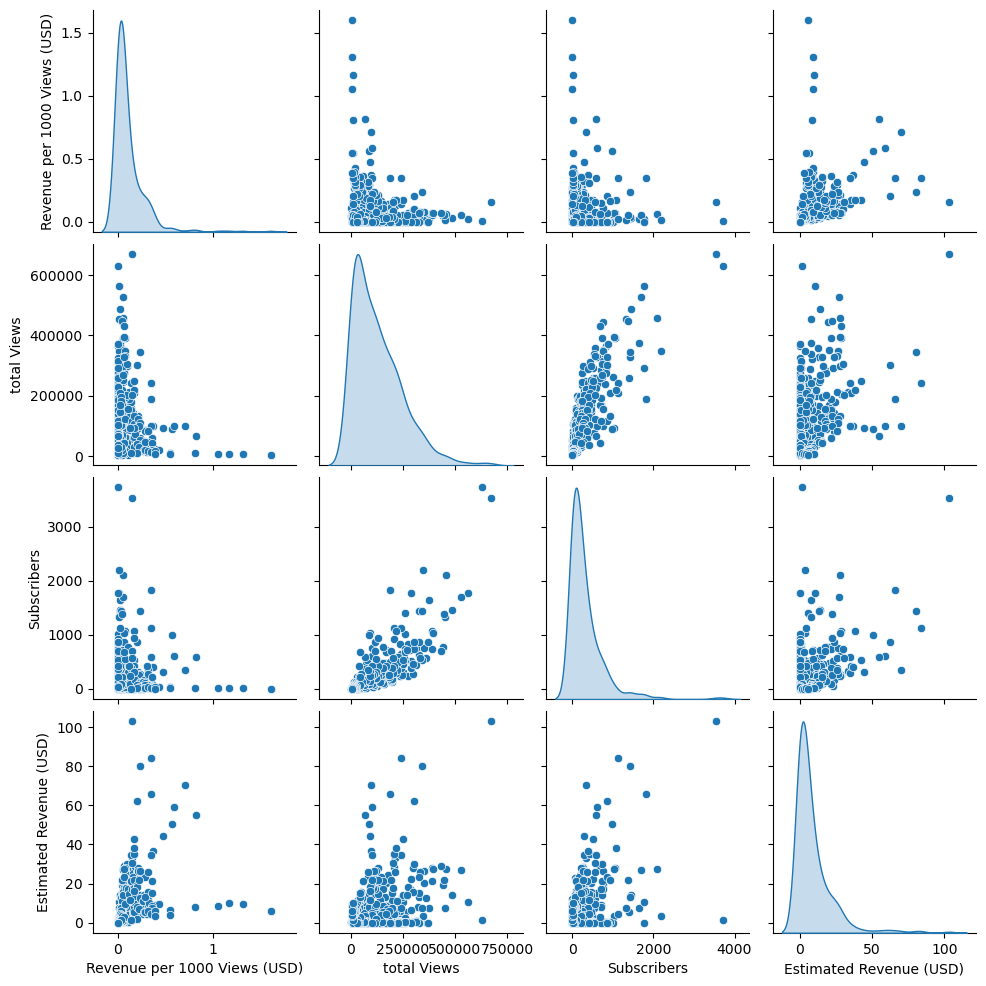

<Figure size 1500x2000 with 0 Axes>

<Figure size 1500x2000 with 0 Axes>

In [14]:
plot_df = df[['Revenue per 1000 Views (USD)', 'total Views',
              'Subscribers', 'Estimated Revenue (USD)']].dropna()

sns.pairplot(plot_df, diag_kind='kde')
plt.show()
plt.figure(figsize=(15,20))


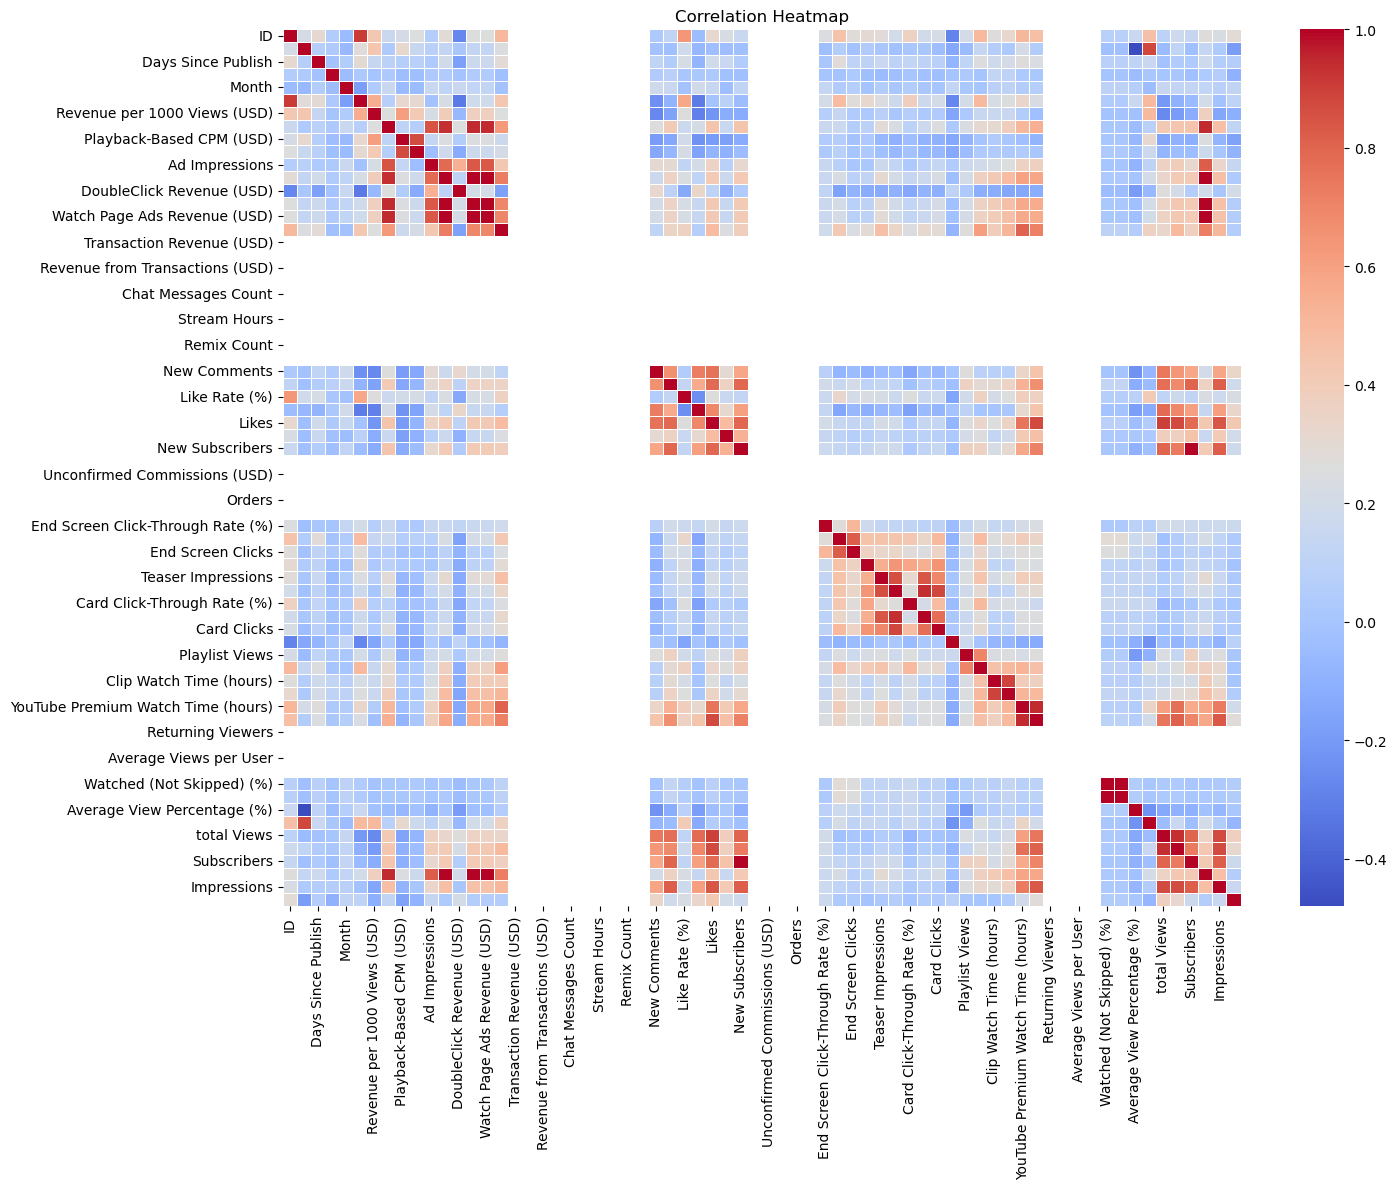

In [45]:
##correlation heatmap
plt.figure(figsize=(15, 12))
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

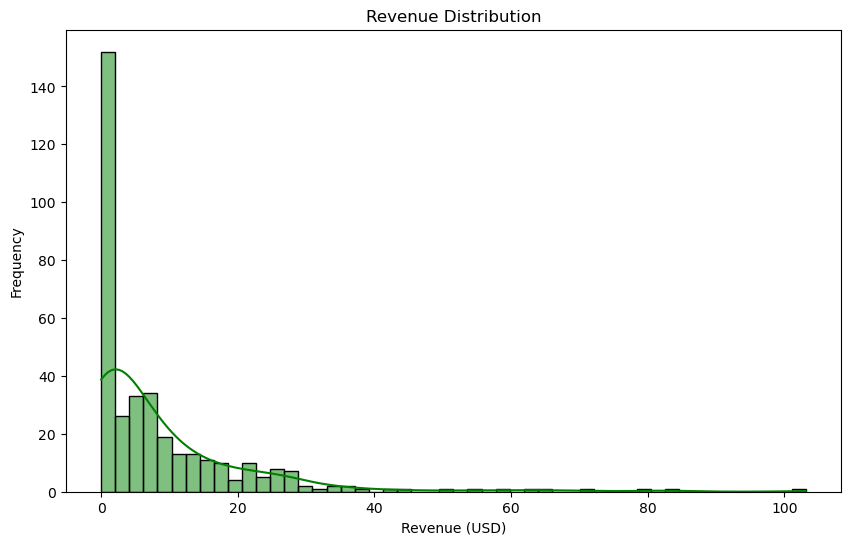

In [30]:
##Data Visualization Revenue Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['Estimated Revenue (USD)'], bins=50,
kde=True, color='green')
plt.title("Revenue Distribution")
plt.xlabel("Revenue (USD)")
plt.ylabel("Frequency")
plt.show()


In [37]:

df.rename(columns={'Estimated Revenue (USD)': 'Revenue'}, inplace=True)

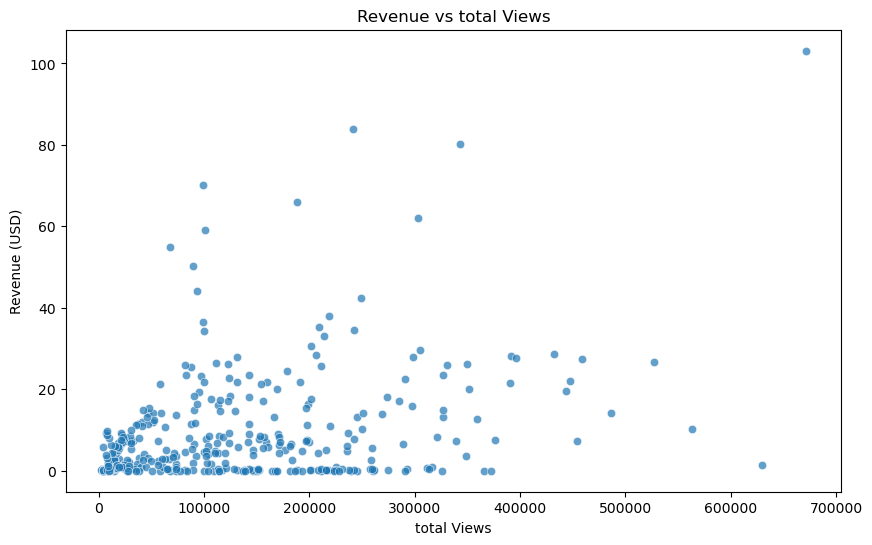

In [41]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df['total Views'],
    y=df['Revenue'],
    alpha=0.7)
plt.title("Revenue vs total Views")
plt.xlabel("total Views")
plt.ylabel("Revenue (USD)")
plt.show()

In [42]:
##While higher views tend to generate higher revenue, the wide dispersion shows that views alone are not a reliable predictor of earnings.

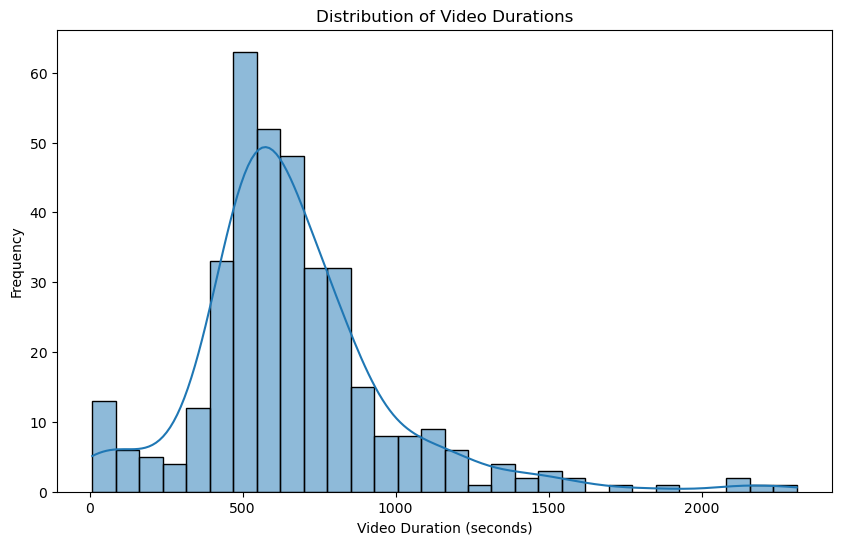

In [43]:
##Distribution of video durations
plt.figure(figsize=(10, 6))
sns.histplot(df['Video Duration'], bins=30, kde=True)
plt.title('Distribution of Video Durations')
plt.xlabel('Video Duration (seconds)')
plt.ylabel('Frequency')
plt.show()